In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Border, Side, Alignment, Font
from openpyxl.utils import get_column_letter
from scipy.stats import beta
from scipy.optimize import curve_fit
import copy

from sklearn.metrics import r2_score

from collections import defaultdict
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')



In [2]:
def load_weather(weather_path, start_year, end_year):    
    # Load the "Hourly" weather data
    
    weather_data = pd.read_csv(weather_path)
    # Slicing the weather data to the dates within the observation year
    weather_data['Date'] = pd.to_datetime(weather_data['Date'], format="%d/%m/%Y", errors='coerce')
    weather_data = weather_data[
        (pd.to_datetime(weather_data['Date'],format="%d/%m/%Y") >= pd.to_datetime(f'{start_year}-1-1')) &
        (pd.to_datetime(weather_data['Date'],format="%d/%m/%Y") <= pd.to_datetime(f'{end_year}-12-31'))]       
    # Renaming the columns and add doy column         
    weather_data = weather_data[['Date', 'Time', 'Temp']].rename(columns={'Date': 'date', 'Time':'Time', 'Temp':'temp'}, inplace=False)
    weather_data.insert(1, 'doy', [d.dayofyear for d in pd.to_datetime(weather_data['date'], format="%d/%m/%Y")])
    # Interpolate missing values
    # Convert '-' to NaN
    weather_data['temp'].replace('-', np.nan, inplace=True)
    weather_data['temp']=weather_data['temp'].apply(pd.to_numeric, errors='coerce')

    # Interpolate missing values
    if weather_data['temp'].isna().any():
        weather_data['temp'].interpolate(method='linear', inplace=True)


    return weather_data.reset_index(drop=True) 

# For single temperature values
def Wangengel(T, MinTemp,OptTemp,MaxTemp,RefTemp):
    RelEff = 0.0
    RelEffRefTemp = 1.0
    p = 0.0

    if MinTemp < T < MaxTemp:
        p = math.log(2.0) / math.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
        RelEff = (2 * (T - MinTemp) ** p * (OptTemp - MinTemp) ** p - (T - MinTemp) ** (2 * p)) / (OptTemp - MinTemp) ** (2 * p)

    if MinTemp < RefTemp < MaxTemp:
        p = math.log(2.0) / math.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
        RelEffRefTemp = (2 * (RefTemp - MinTemp) ** p * (OptTemp - MinTemp) ** p - (RefTemp - MinTemp) ** (2 * p)) / (OptTemp - MinTemp) ** (2 * p)

    return float(RelEff / RelEffRefTemp)


def cool_response_linear(T, T_crit=15.0, T_base=3.0):
    """
    Cool-weighted temperature response for Hayward SSC.
    
    Parameters
    ----------
    T : float or array
        Mean daily temperature (°C)
    T_crit : float
        Temperature above which SSC accumulation is inactive
    T_base : float
        Lower bound for full response
    
    Returns
    -------
    f : float or array
        Dimensionless daily forcing (0--1)
    """
    T = np.asarray(T)

    f = np.zeros_like(T, dtype=float)

    mask1 = (T < T_crit) & (T > T_base)
    f[mask1] = (T_crit - T[mask1]) / (T_crit - T_base)

    f[T <= T_base] = 1.0
    f[T >= T_crit] = 0.0

    return f

def linear_relationship(x,a,b):
    return a*x + b
def sigmoid(x,
            y_min,
            y_max,
            b,
            x_crit):
    return y_min + (y_max - y_min) / (
        1.0 + np.exp(-(x - x_crit)/b))

def asymmetric_gaussian(x, A, mu, sigma_left, sigma_right):
    sigma = np.where(x < mu, sigma_left, sigma_right)
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

In [3]:
file_path = './KRIP_hayward_fruit_quality_data/20260522_DatasetForJemBurdon_MaturityAreaPredictions2026_YieldAndProfileAdded.xlsx'
xls = pd.ExcelFile(file_path, engine="openpyxl")
Report = pd.read_excel(xls, sheet_name = 'YieldAndProfileData')
auxilliary_report = pd.read_excel(xls, sheet_name = 'HwMaturityAreas')


In [4]:
list_of_interested_columns = ['GrowerMaturityAreaKey',
                              'Season',
                              'TotalKgsPerHa',
                              'Size18_Perc',
                              'Size22_Perc',
                              'Size25_Perc',
                              'Size27_Perc',
                              'Size30_Perc',
                              'Size33_Perc',
                              'Size36_Perc',
                              'Size39_Perc',
                              'Size42_Perc',
                              'Size46_Perc']


Report = Report[list_of_interested_columns].reset_index(drop=True)

In [5]:
list_of_columns_to_median = ['TotalKgsPerHa',
                              'Size18_Perc',
                              'Size22_Perc',
                              'Size25_Perc',
                              'Size27_Perc',
                              'Size30_Perc',
                              'Size33_Perc',
                              'Size36_Perc',
                              'Size39_Perc',
                              'Size42_Perc',
                              'Size46_Perc']

SizeCodeToKg ={'Size18_Perc': np.mean([0.180,0.210]),
            'Size22_Perc': np.mean([0.150,0.180]),
            'Size25_Perc': np.mean([0.138,0.150]),
            'Size27_Perc': np.mean([0.128,0.138]),
            'Size30_Perc': np.mean([0.118,0.128]),
            'Size33_Perc': np.mean([0.106,0.118]),
            'Size36_Perc': np.mean([0.091,0.106]),
            'Size39_Perc': np.mean([0.082,0.091]),
            'Size42_Perc': np.mean([0.074,0.082]),
            'Size46_Perc': np.mean([0.072,0.074])}

Grower_kg_per_hec = defaultdict()
# Grower: 18966, Year: 2023
check = Report[(Report['GrowerMaturityAreaKey'].isin(['18966_1','18966_3','18966_4'])) & (Report['Season']==2023)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['18966_2023'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa'] 

# Grower: 57575, Year: 2023
check = Report[(Report['GrowerMaturityAreaKey'].isin(['57575_1','57575_2','57575_3'])) & (Report['Season']==2023)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['57575_2023'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
# Grower: 57575, Year: 2024
check = Report[(Report['GrowerMaturityAreaKey'].isin(['57575_1','57575_2','57575_3'])) & (Report['Season']==2024)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['57575_2024']  = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
# Grower: 57575, Year: 2025
check = Report[(Report['GrowerMaturityAreaKey'].isin(['57575_1','57575_2','57575_3'])) & (Report['Season']==2025)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['57575_2025']  = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']

# Grower: 58585, Year: 2023
check = Report[(Report['GrowerMaturityAreaKey'].isin(['58585_HW1','58585_HW2'])) & (Report['Season']==2023)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['58585_2023'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
# Grower: 58585, Year: 2024
check = Report[(Report['GrowerMaturityAreaKey'].isin(['58585_HW1','58585_HW2'])) & (Report['Season']==2024)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['58585_2024'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
# Grower: 58585, Year: 2025
check = Report[(Report['GrowerMaturityAreaKey'].isin(['58585_HW1','58585_HW2'])) & (Report['Season']==2025)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['58585_2025'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']

# Grower: 64052, Year: 2024
check = Report[(Report['GrowerMaturityAreaKey'].isin(['64052_HWC','64052_HWD'])) & (Report['Season']==2024)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['64052_2024'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
# Grower: 64052, Year: 2025
check = Report[(Report['GrowerMaturityAreaKey'].isin(['64052_HWC','64052_HWD'])) & (Report['Season']==2025)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['64052_2025'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']


# Grower: 75554, Year: 2023
check = Report[(Report['GrowerMaturityAreaKey'].isin(['75554_F','75554_G'])) & (Report['Season']==2023)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['75554_2023'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
size_proportion = (check_median).to_frame()
size_proportion

# Grower: 75554, Year: 2024
check = Report[(Report['GrowerMaturityAreaKey'].isin(['75554_F','75554_G'])) & (Report['Season']==2024)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['75554_2024'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
# Grower: 75554, Year: 2025
check = Report[(Report['GrowerMaturityAreaKey'].isin(['75554_F','75554_G'])) & (Report['Season']==2025)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['75554_2025'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']

# Grower: 83765, Year: 2023
check = Report[(Report['GrowerMaturityAreaKey'].isin(['83765_A'])) & (Report['Season']==2023)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['83765_2023'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
# Grower: 83765, Year: 2024
check = Report[(Report['GrowerMaturityAreaKey'].isin(['83765_A'])) & (Report['Season']==2024)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['83765_2024'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']
# Grower: 83765, Year: 2025
check = Report[(Report['GrowerMaturityAreaKey'].isin(['83765_A'])) & (Report['Season']==2025)]
check_median = check[list_of_columns_to_median].median()
Grower_kg_per_hec['83765_2025'] = check_median[SizeCodeToKg.keys()] * check_median['TotalKgsPerHa']

Grower_kg_per_hec = pd.DataFrame(Grower_kg_per_hec)

In [6]:
hec_to_m2 = 1e-4
fruits_per_m2_per_size = defaultdict(list)
for col in Grower_kg_per_hec.columns:
    for size in Grower_kg_per_hec[col].index:
        fruit_num_per_size = Grower_kg_per_hec[col][size] / SizeCodeToKg[size] * hec_to_m2
        fruits_per_m2_per_size['Growers'].append(col)
        fruits_per_m2_per_size['Size'].append(size)
        fruits_per_m2_per_size['Fruit Number'].append(fruit_num_per_size)

fruits_per_m2_per_size = pd.DataFrame(fruits_per_m2_per_size)   
fruits_per_m2_per_size[(fruits_per_m2_per_size['Growers']=='75554_2023')]

,Growers,Size,Fruit Number
90,75554_2023,Size18_Perc,0.030492
91,75554_2023,Size22_Perc,0.668815
92,75554_2023,Size25_Perc,1.518631
93,75554_2023,Size27_Perc,2.448617
94,75554_2023,Size30_Perc,3.563353
95,75554_2023,Size33_Perc,5.203756
96,75554_2023,Size36_Perc,5.320441
97,75554_2023,Size39_Perc,1.726263
98,75554_2023,Size42_Perc,0.721987
99,75554_2023,Size46_Perc,0.057906


<Axes: xlabel='Size', ylabel='Fruit Number'>

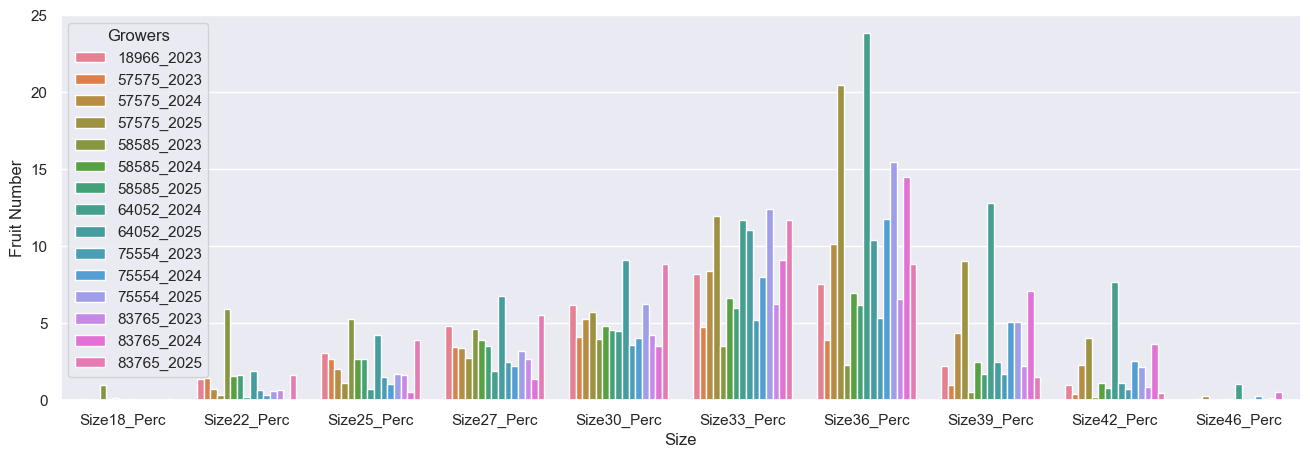

In [7]:
sns.set_theme(rc={'figure.figsize': (16, 5)})
sns.barplot(fruits_per_m2_per_size, x='Size', y='Fruit Number', hue='Growers')

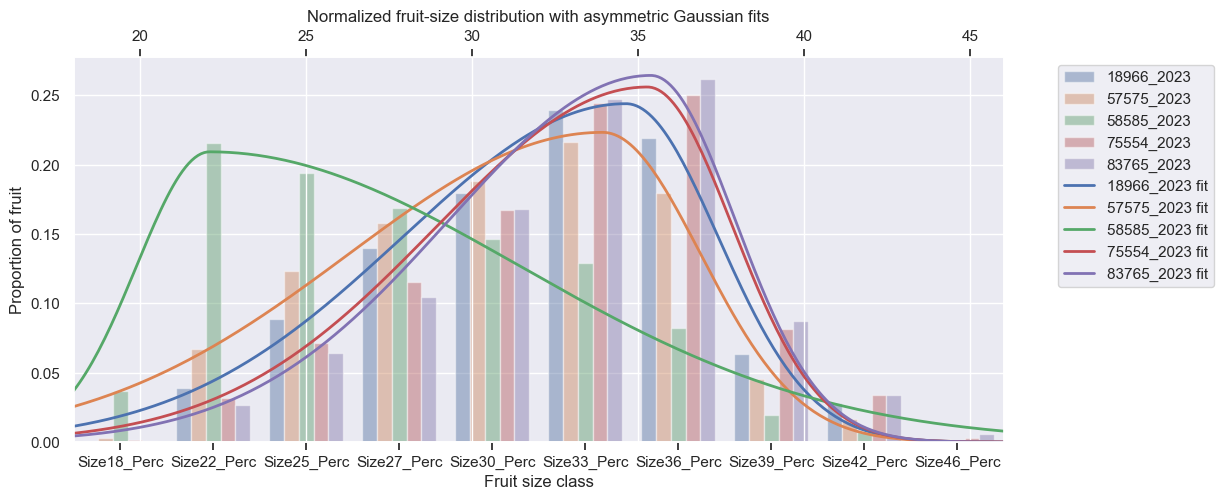

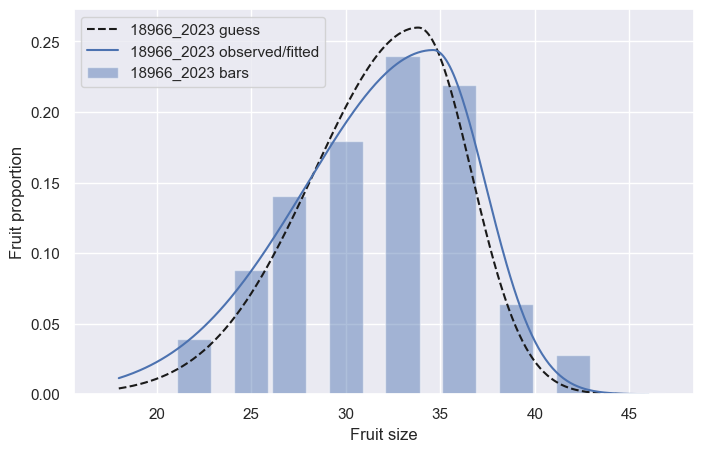

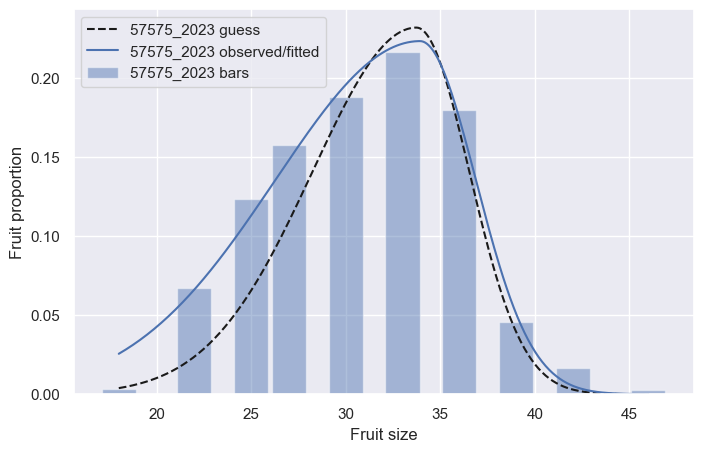

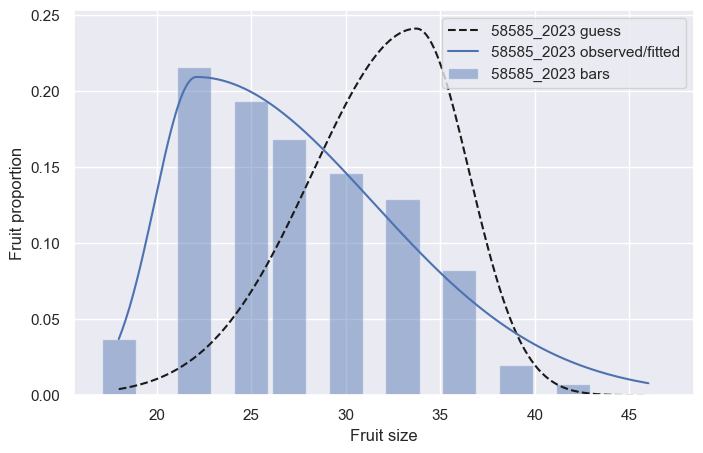

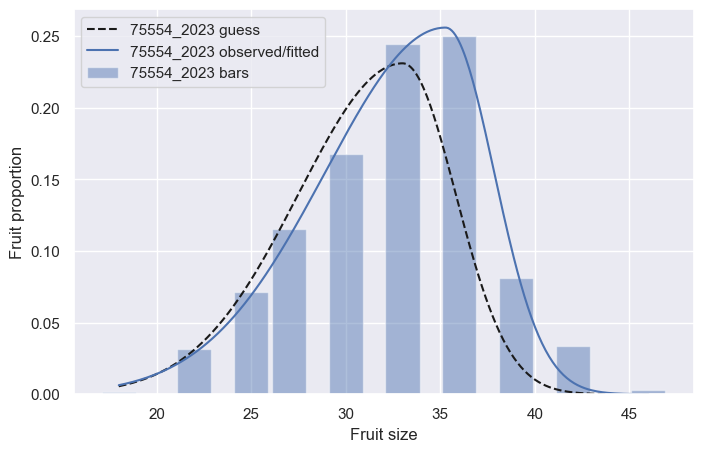

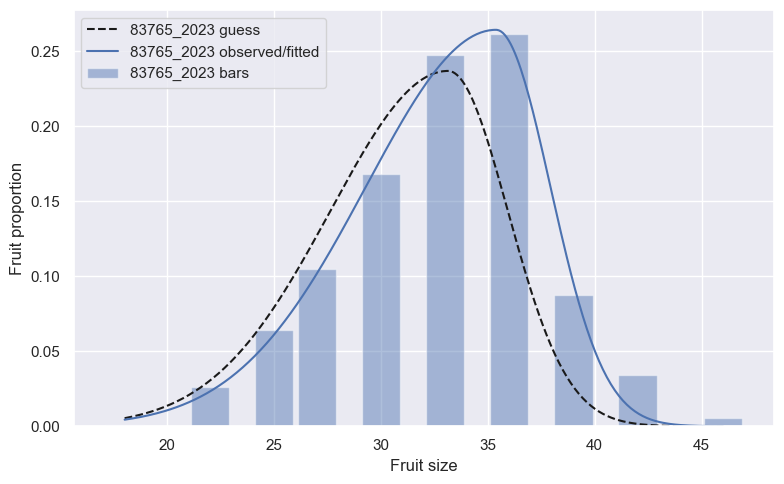

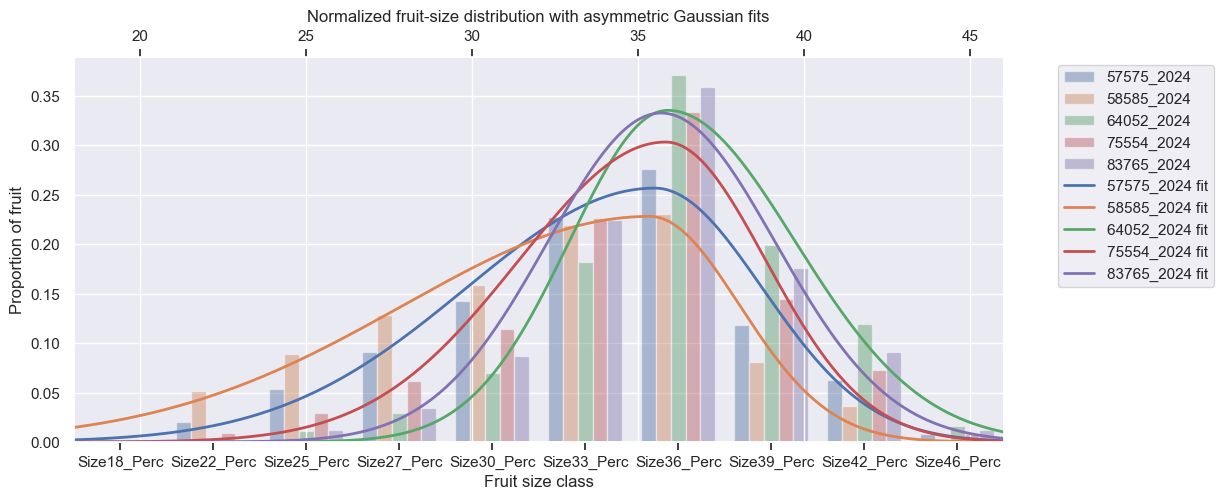

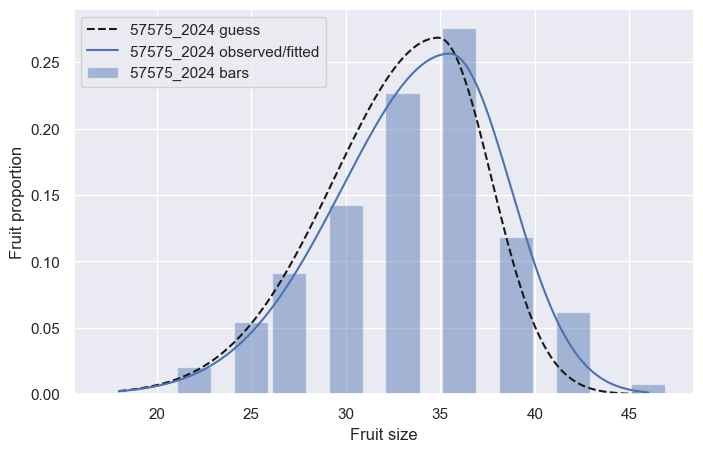

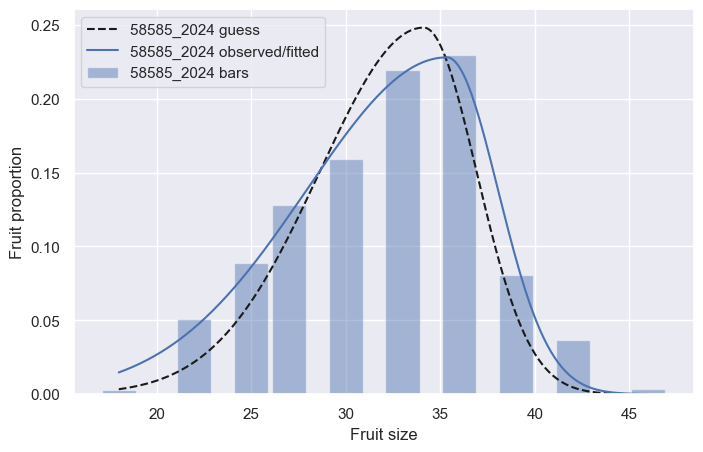

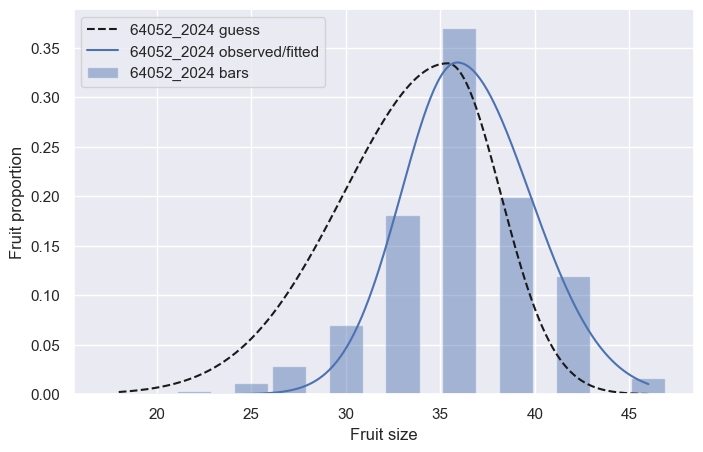

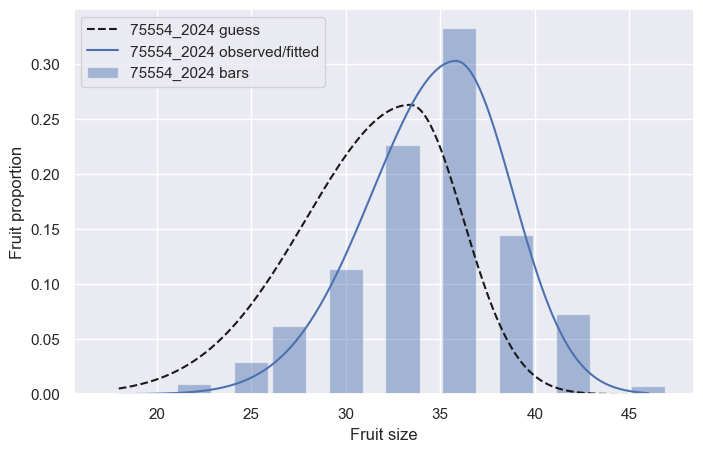

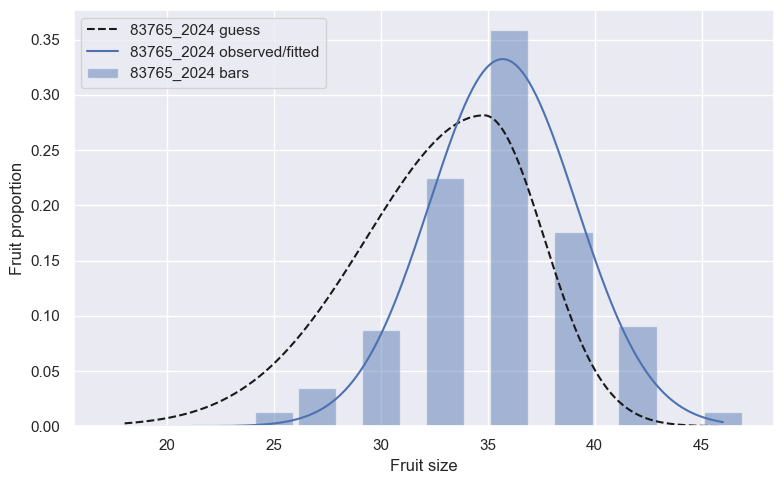

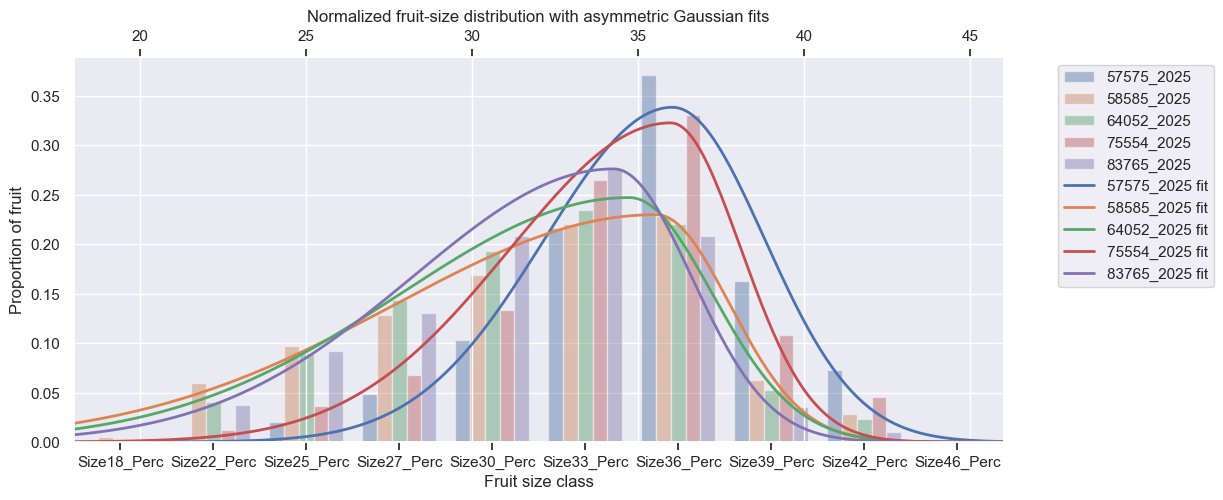

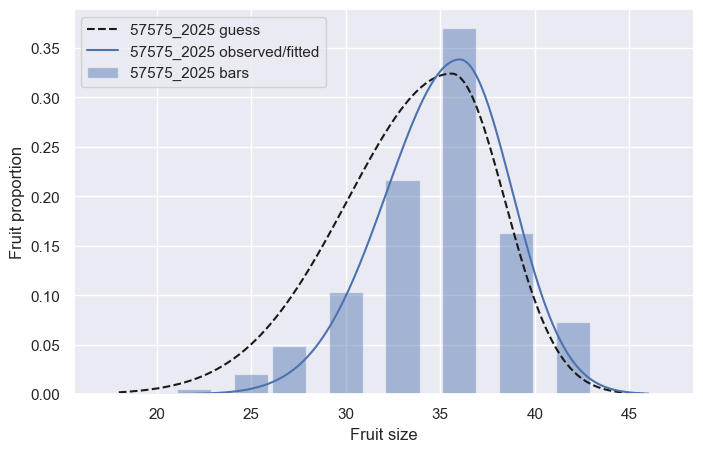

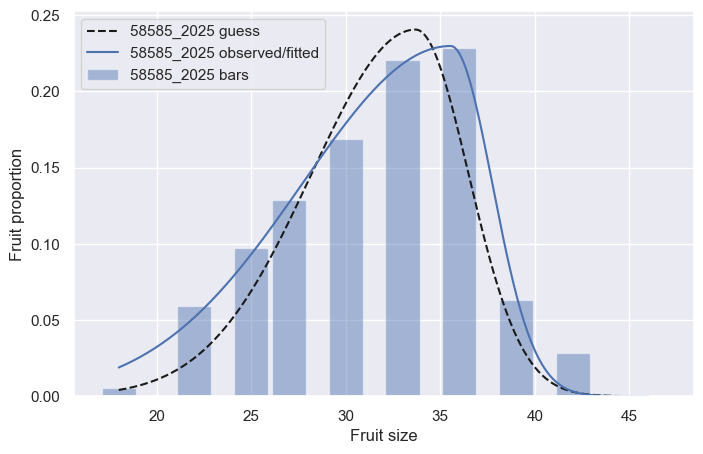

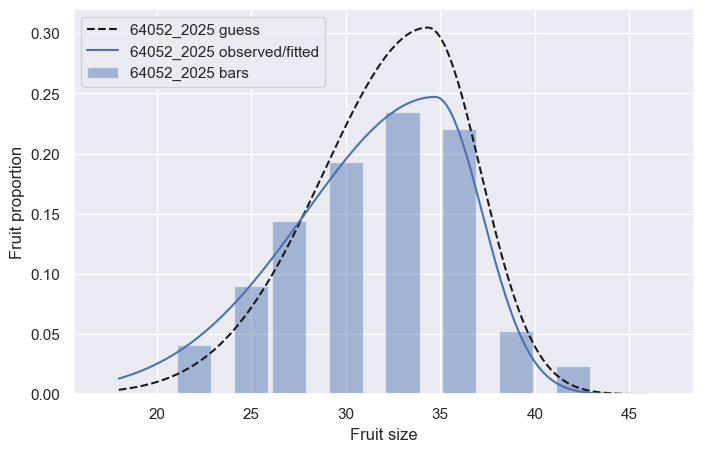

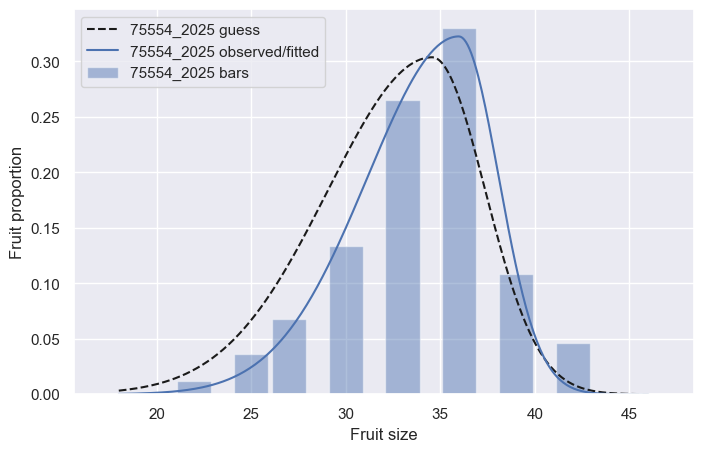

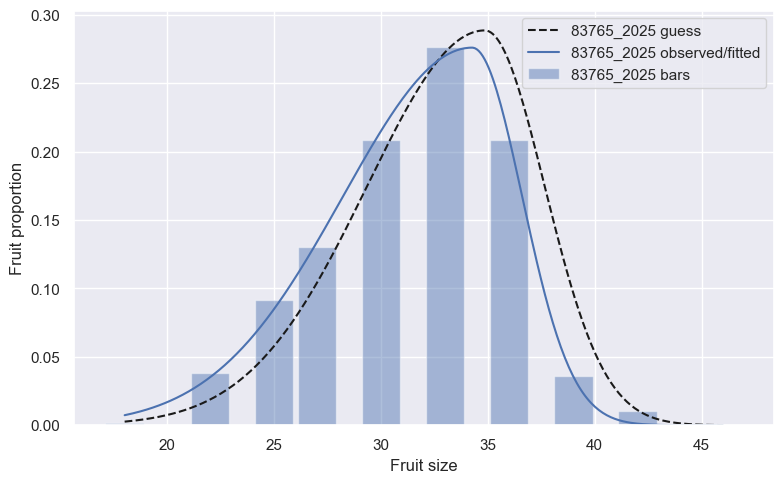

In [ ]:
sns.set_theme(rc={'figure.figsize': (12, 4)})

grower_years = {
    2023: ['18966_2023','57575_2023','58585_2023','75554_2023','83765_2023'],
    2024: ['57575_2024','58585_2024','64052_2024','75554_2024','83765_2024'],
    2025: ['57575_2025','58585_2025','64052_2025','75554_2025','83765_2025']}

apsim_fw = {'18966_2023':111.73,'57575_2023':112.19,'58585_2023':112.18,'75554_2023':115.44,'83765_2023':114.89,
            '57575_2024':107,'58585_2024':110.48,'64052_2024':104.8,'75554_2024':113.64,'83765_2024':107.32,
            '57575_2025':103.86,'58585_2025':112.39,'64052_2025':109.48,'75554_2025':108.48,'83765_2025':107.21}


def plot_bar_gaussian(fruits_per_m2_per_size, grower_year, normalize=False):

    plot_df = fruits_per_m2_per_size[fruits_per_m2_per_size["Growers"].isin(grower_year)].copy()

    plot_df["Fruit Number"] = pd.to_numeric(plot_df["Fruit Number"], errors="coerce")

    # Keep original label for bar chart
    plot_df["Size_label"] = plot_df["Size"].astype(str)

    # Extract actual size class number, e.g. Size18_Perc -> 18
    plot_df["Size_numeric"] = (
        plot_df["Size"]
        .astype(str)
        .str.extract(r"Size(\d+)_Perc")[0]
        .astype(float))

    plot_df = plot_df.dropna(subset=["Size_numeric", "Fruit Number"])

    # -------------------------------------------------
    # Normalize bars and fitted values within each grower
    # -------------------------------------------------
    if normalize:
        plot_df["Fruit Number Plot"] = (
            plot_df.groupby("Growers")["Fruit Number"]
            .transform(lambda x: x / x.sum() if x.sum() > 0 else x)
        )
        y_label = "Proportion of fruit"
        title = "Normalized fruit-size distribution with asymmetric Gaussian fits"
    else:
        plot_df["Fruit Number Plot"] = plot_df["Fruit Number"]
        y_label = "Fruit number per m²"
        title = "Fruit-size distribution with asymmetric Gaussian fits"

    fig, ax_bar = plt.subplots(figsize=(12, 5))

    # Bar chart
    sns.barplot(
        data=plot_df,
        x="Size_label",
        y="Fruit Number Plot",
        hue="Growers",
        hue_order=grower_year,
        alpha=0.45,
        ax=ax_bar)

    ax_bar.set_xlabel("Fruit size class")
    ax_bar.set_ylabel(y_label)
    ax_bar.set_title(title)

    # Independent numeric x-axis for fitted Gaussian curves
    ax_fit = ax_bar.twiny()

    fit_results = []

    for grower, g in plot_df.groupby("Growers"):

        g_fit = (
            g.groupby("Size_numeric", as_index=False)["Fruit Number Plot"]
            .sum()
            .sort_values("Size_numeric"))

        x = g_fit["Size_numeric"].values.astype(float)
        y = g_fit["Fruit Number Plot"].values.astype(float)

        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        if len(x) < 4 or y.max() <= 0:
            print(f"Not enough data to fit {grower}")
            continue

        A0 = y.max()
        mu0 = x[np.argmax(y)]
        sigma0 = np.std(x)

        if not np.isfinite(sigma0) or sigma0 <= 0:
            sigma0 = 1.0

        p0 = [A0, mu0, sigma0, sigma0]

        bounds = (
            [0, x.min(), 0.01, 0.01],
            [np.inf, x.max(), np.inf, np.inf])

        try:
            popt, pcov = curve_fit(
                asymmetric_gaussian,
                x,
                y,
                p0=p0,
                bounds=bounds,
                maxfev=10000)

            A, mu, sigma_left, sigma_right = popt

            x_smooth = np.linspace(x.min(), x.max(), 300)
            y_smooth = asymmetric_gaussian(x_smooth, A, mu, sigma_left, sigma_right)

##################################################################################
############ Gaussian Estimations from APSIM FW predictions ######################
            fruit_num_m2_by_grower = plot_df.groupby('Growers')["Fruit Number"].sum()
            fruit_num_m2 = fruit_num_m2_by_grower.loc[grower]
            A_peak_est = sigmoid(fruit_num_m2, 0.22, 0.34, 8.18, 40)
            mu_est = linear_relationship(apsim_fw[grower], -0.2242, 58.89)
            SI = -0.45*math.tanh(0.4*(mu_est-33))
            sigma_left_est = 4.2*(1-SI)
            sigma_right_est = 4.2*(1+SI)

            y_guess1 = asymmetric_gaussian(x_smooth, A_peak_est, mu_est, sigma_left_est, sigma_right_est)
            sigma_left_est = 2.5 if mu_est<30 else 5.5
            sigma_right_est = 9 if mu_est<30 else 2.8
            y_guess2 = asymmetric_gaussian(x_smooth, A_peak_est, mu_est, sigma_left_est, sigma_right_est)
            

            size_midpoints = {
                "Size18_Perc": 18,
                "Size22_Perc": 22,
                "Size25_Perc": 25,
                "Size27_Perc": 27,
                "Size30_Perc": 30,
                "Size33_Perc": 33,
                "Size36_Perc": 36,
                "Size39_Perc": 39,
                "Size42_Perc": 42,
                "Size46_Perc": 46}

            grower_df = plot_df[plot_df["Growers"] == grower].copy()
            grower_df["Size_numeric"] = grower_df["Size_label"].map(size_midpoints)

            fig, ax = plt.subplots(figsize=(8, 5))

            ax.bar(
                grower_df["Size_numeric"],
                grower_df["Fruit Number Plot"],
                alpha=0.45,
                width=1.8,
                label=f"{grower} bars")

            # ax.plot(x_smooth, y_guess1, 'k--', label=f'{grower} guess')
            ax.plot(x_smooth, y_guess2, 'k--', label=f'{grower} guess')
            ax.plot(x_smooth, y_smooth, label=f'{grower} observed/fitted')

            ax.set_xlabel("Fruit size")
            ax.set_ylabel("Fruit proportion")
            ax.legend()
            
######################################################################################    
      
            # The bars and fitted curve are already fitted to normalized values
            # if normalize=True.
            y_plot = y_smooth

            ax_fit.plot(
                x_smooth,
                y_plot,
                linewidth=2,
                label=f"{grower} fit")

            fit_results.append({
                "Grower": grower,
                "A_peak": A,
                "mu_size": mu,
                "sigma_left": sigma_left,
                "sigma_right": sigma_right,
                "normalized": normalize })

        except RuntimeError:
            print(f"Fit failed for {grower}")

        
    xmin = plot_df["Size_numeric"].min()
    xmax = plot_df["Size_numeric"].max()

    if np.isfinite(xmin) and np.isfinite(xmax):
        ax_fit.set_xlim(xmin, xmax)

    # ax_fit.set_xlabel("Numeric fruit size class used for Gaussian fit")
    ax_fit.set_ylim(ax_bar.get_ylim())

    handles_bar, labels_bar = ax_bar.get_legend_handles_labels()
    handles_fit, labels_fit = ax_fit.get_legend_handles_labels()

    ax_bar.legend(
        handles_bar + handles_fit,
        labels_bar + labels_fit,
        bbox_to_anchor=(1.05, 1),
        loc="upper left")

    if ax_fit.get_legend() is not None:
        ax_fit.get_legend().remove()

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(fit_results)

fit_results = defaultdict()

for year, grower_year in grower_years.items():
    fit_results[year] = plot_bar_gaussian(
        fruits_per_m2_per_size,
        grower_year,
        normalize=True)

In [9]:
total_fruits_per_m2 = fruits_per_m2_per_size.groupby(['Growers']).sum().reset_index()
# total_fruits_per_m2['DMC'] = [17.6,18.1,17.3,17.9,16.3,17.15,17.45,17.15,17.6,17.6,18.85,17.7,18.5,17.2,18]
# total_fruits_per_m2['FW'] = [112,112,98.5,98.5,165,112,112,98.5,112,112,98.5,98.5,112,98.5,112]
# total_fruits_per_m2['DW'] = [19.7,20.27,17,17.63,28.79,19.2,19.5,16.9,19.7,19.7,18.56,17.43,20.72,16.94,20.16]
# total_fruits_per_m2['AccTT_Mature'] = [3813,2906,2748,2865,3009,2812,2843,3410,3740,3742,3348,3545,3703,3921,2820]
total_fruits_per_m2

,Growers,Size,Fruit Number
0,18966_2023,Size18_PercSize22_PercSize25_PercSize27_PercSi...,34.283558
1,57575_2023,Size18_PercSize22_PercSize25_PercSize27_PercSi...,21.885623
2,57575_2024,Size18_PercSize22_PercSize25_PercSize27_PercSi...,36.816390
3,57575_2025,Size18_PercSize22_PercSize25_PercSize27_PercSi...,55.261444
4,58585_2023,Size18_PercSize22_PercSize25_PercSize27_PercSi...,27.342860
5,58585_2024,Size18_PercSize22_PercSize25_PercSize27_PercSi...,30.298499
6,58585_2025,Size18_PercSize22_PercSize25_PercSize27_PercSi...,27.115888
7,64052_2024,Size18_PercSize22_PercSize25_PercSize27_PercSi...,64.336229
8,64052_2025,Size18_PercSize22_PercSize25_PercSize27_PercSi...,47.144086
9,75554_2023,Size18_PercSize22_PercSize25_PercSize27_PercSi...,21.260261


In [10]:
fit_results

defaultdict(None,
            {2023:        Grower    A_peak    mu_size  sigma_left  sigma_right  normalized
             0  18966_2023  0.243939  34.633421    6.720943     2.773447        True
             1  57575_2023  0.223267  33.927918    7.651713     2.955036        True
             2  58585_2023  0.209246  22.094619    2.198897     9.340134        True
             3  75554_2023  0.255969  35.274793    6.350740     2.568581        True
             4  83765_2023  0.264304  35.381347    6.069969     2.537361        True,
             2024:        Grower    A_peak    mu_size  sigma_left  sigma_right  normalized
             0  57575_2024  0.256484  35.498253    5.677473     3.238945        True
             1  58585_2024  0.227944  35.347654    7.414040     2.704735        True
             2  64052_2024  0.335023  35.884508    2.954092     3.831495        True
             3  75554_2024  0.303011  35.825751    4.417554     3.010784        True
             4  83765_2024  0.3322

array([-0.22425833, 58.89040666])

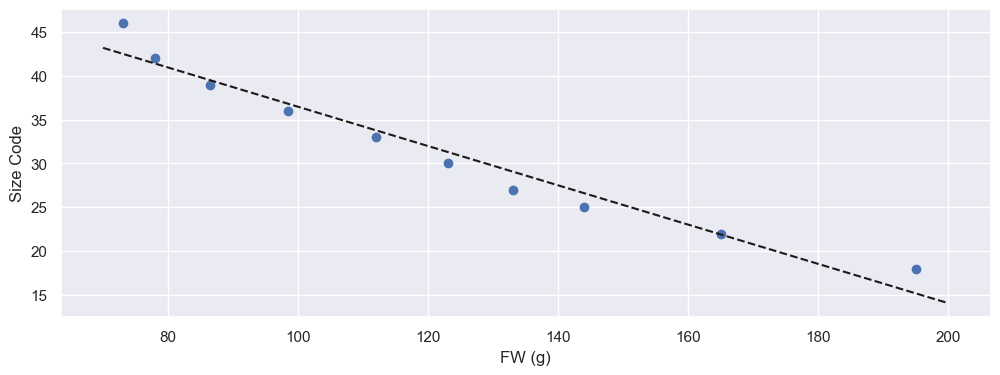

In [41]:
# Turn fruit code size to FW
init_df  = [df['mu_size'] for df in fit_results.values()] 
mu_size = pd.concat(init_df, ignore_index=True)


NumericalSizeCodeTog = {18: np.float64(195),
 22: np.float64(165),
 25: np.float64(144),
 27: np.float64(133),
 30: np.float64(123),
 33: np.float64(112),
 36: np.float64(98.5),
 39: np.float64(86.5),
 42: np.float64(78),
 46: np.float64(73)}

plt.scatter(NumericalSizeCodeTog.values(), NumericalSizeCodeTog.keys())

popt,_ = curve_fit(linear_relationship, list(NumericalSizeCodeTog.values()), list(NumericalSizeCodeTog.keys()))

x_continuous = np.linspace(70,200,200)
y_continuous = linear_relationship(x_continuous, *popt)
plt.plot(x_continuous,y_continuous, 'k--')
plt.xlabel('FW (g)')
plt.ylabel('Size Code')

popt

In [ ]:
# Fruit proportion & Fruit number
init_df  = [df[['Grower','A_peak']] for df in fit_results.values()]
peaks = pd.concat(init_df, ignore_index=True)

x = []
for grower in peaks['Grower']:
    x.append(total_fruits_per_m2[(total_fruits_per_m2['Growers']==grower)]['Fruit Number'].iloc[0])

peaks['Fruit Number'] = x
peaks

,Grower,A_peak,Fruit Number
0,18966_2023,0.243939,34.283558
1,57575_2023,0.223267,21.885623
2,58585_2023,0.209246,27.342860
3,75554_2023,0.255969,21.260261
4,83765_2023,0.264304,25.205472
5,57575_2024,0.256484,36.816390
6,58585_2024,0.227944,30.298499
7,64052_2024,0.335023,64.336229
8,75554_2024,0.303011,35.263233
9,83765_2024,0.332298,40.386261


In [13]:
peaks[['Fruit Number','A_peak']].corr(method='pearson')

,Fruit Number,A_peak
Fruit Number,1.000000,0.751834
A_peak,0.751834,1.000000


Text(0.5, 1.0, 'Fruit distribution peak value')

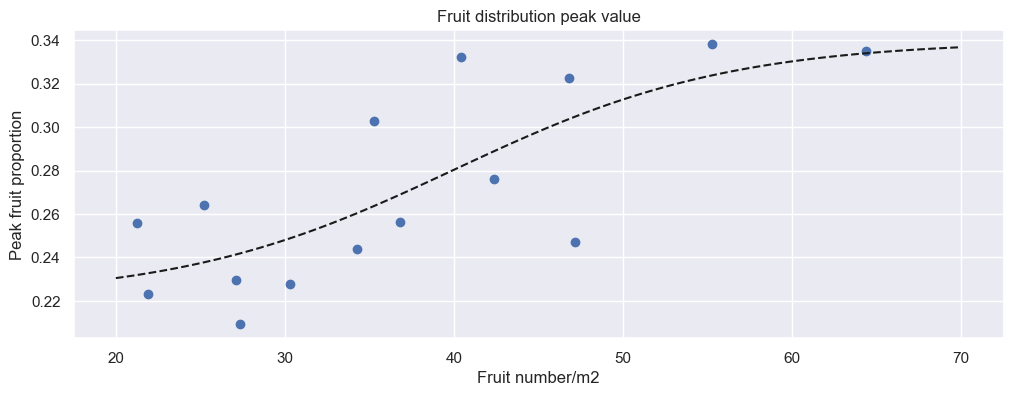

In [ ]:
plt.scatter(peaks['Fruit Number'], peaks['A_peak'])

bounds = [
    (0.22, 0.22, 1, 30),
    (0.26, 0.35, 10, 40)
]
popt, _ = curve_fit(sigmoid, peaks['Fruit Number'], peaks['A_peak'], bounds = bounds)

x_continuous = np.linspace(20,70,100)
y_continuous = sigmoid(x_continuous, *popt)

plt.plot(x_continuous, y_continuous, 'k--')
plt.xlabel('Fruit number/m2')
plt.ylabel('Peak fruit proportion')
plt.title('Fruit distribution peak value')

In [15]:
popt

array([ 0.22102292,  0.33981499,  8.18066853, 39.9999975 ])

In [16]:
# CORRELATION
total_fruits_per_m2[['Fruit Number','DMC','FW', 'DW', 'AccTT_Mature']].corr(method='pearson')

KeyError: "['DMC', 'FW', 'DW', 'AccTT_Mature'] not in index"

In [ ]:
plt.scatter(total_fruits_per_m2['AccTT_Mature'],total_fruits_per_m2['DMC'])
plt.xlabel('AccTT_Mature')
plt.ylabel('DMC')

# # LINEAR
# popt,_ = curve_fit(linear_relationship, total_fruits_per_m2['DW'],total_fruits_per_m2['FW'])
# print(popt)
# x_dw = np.linspace(15,30,100)
# y_fw = linear_relationship(x_dw, popt[0], popt[1])
# plt.plot(x_dw, y_fw, 'k--')

# SIGMOID
# bounds = [(0,165,1,17), (0.05,175,4.5,20)]
# popt,_ = curve_fit(sigmoid, total_fruits_per_m2['DW'],total_fruits_per_m2['FW'], bounds=bounds)
# print(popt)
# x_dw = np.linspace(0,30,100)
# y_fw = sigmoid(x_dw, *popt)
# plt.plot(x_dw, y_fw, 'k--')